In [1]:
import numpy as np

v = np.array([3, -4])
w = np.array([1, 1, 1, 1])
a = np.array([1, 2])
b = np.array([4, 6])


In [6]:
# Calcualting L1, L2 and L∞ norms of vector v

print('L1 norm of v : ', np.linalg.norm(v,ord = 1))
print('L2 norm of v : ', np.linalg.norm(v,ord = 2))
print('L∞ norm of v : ',np.linalg.norm(v,ord=np.inf))

L1 norm of v :  7.0
L2 norm of v :  5.0
L∞ norm of v :  4.0


In [8]:
# Calcualting L1, L2 and L∞ norms of vector w

print('L1 norm of w : ', np.linalg.norm(w,ord = 1))
print('L2 norm of w : ', np.linalg.norm(w,ord = 2))
print('L∞ norm of w : ',np.linalg.norm(w,ord=np.inf))

L1 norm of w :  4.0
L2 norm of w :  2.0
L∞ norm of w :  1.0


In [11]:
# Building method to caluclate L1, L2 and L∞ norms

def l1_norm(v):
    return np.sum(np.abs(v))

def l2_norm(v):
    return np.sqrt(np.sum(v ** 2))
    
def linf_norm(v):
    return np.max(np.abs(v))    

# Test on v = [3, -4]
print(l1_norm(v), l2_norm(v), linf_norm(v))   

# Test on w = [1, 1, 1, 1]
print(l1_norm(w), l2_norm(w), linf_norm(w))   

7 5.0 4
4 2.0 1


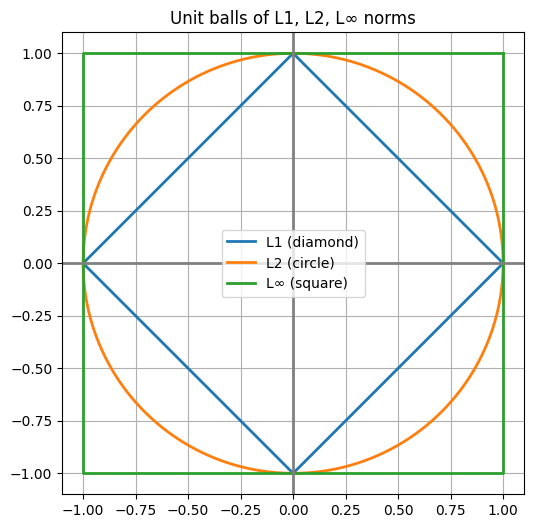

In [30]:
import matplotlib.pyplot as plt

# Sample many points on each unit ball
theta = np.linspace(0, 2 * np.pi, 200)

# # L2 unit ball: circle
l2_x = np.cos(theta)
l2_y = np.sin(theta)

# # L1 unit ball: diamond — |x| + |y| = 1
l1_x = [1, 0, -1, 0, 1]
l1_y = [0, 1, 0, -1, 0]

# L∞ unit ball: square — max(|x|, |y|) = 1
linf_x = [1, -1, -1, 1, 1]
linf_y = [1, 1, -1, -1, 1]

plt.figure(figsize=(6, 6))
# Plotting the vectors
plt.plot(l1_x, l1_y, label='L1 (diamond)', linewidth=2)
plt.plot(l2_x, l2_y, label='L2 (circle)', linewidth=2)
plt.plot(linf_x, linf_y, label='L∞ (square)', linewidth=2)

# Defining the graph structure
plt.axhline(0, color='gray', linewidth=2.0)
plt.axvline(0, color='gray', linewidth=2.0)
plt.grid(True)
plt.gca().set_aspect('equal')
plt.legend()
plt.title("Unit balls of L1, L2, L∞ norms")

# Plotting the graph
plt.show()

In [33]:
# L1 > L2 > L∞ norms always
# A quick sanity check

test_vectors = [
    np.array([3, -4]),
    np.array([1, 1, 1, 1]),
    np.array([5, 0, 0]),
    np.array([2, 2, 2, 2, 2]),
]

for v in test_vectors:
    l1 = l1_norm(v)
    l2 = l2_norm(v)
    linf = linf_norm(v)
    print(f"v = {v}  →  L1 = {l1}, L2 = {l2:.3f}, L∞ = {linf}  →  L1 ≥ L2 ≥ L∞: {l1 >= l2 >= linf}")

v = [ 3 -4]  →  L1 = 7, L2 = 5.000, L∞ = 4  →  L1 ≥ L2 ≥ L∞: True
v = [1 1 1 1]  →  L1 = 4, L2 = 2.000, L∞ = 1  →  L1 ≥ L2 ≥ L∞: True
v = [5 0 0]  →  L1 = 5, L2 = 5.000, L∞ = 5  →  L1 ≥ L2 ≥ L∞: True
v = [2 2 2 2 2]  →  L1 = 10, L2 = 4.472, L∞ = 2  →  L1 ≥ L2 ≥ L∞: True


In [45]:
# Norms in ML has three use cases we will see each one of them one by one.

# Use case 1 : predicting error    
actual    = np.array([310, 450, 230, 510, 380])
predicted = np.array([310, 450, 230, 510, 380])

error = predicted - actual

print(f"L1 norm error (MAE) : {l1_norm(error):.2f}")
print(f"L2 error (RMSE-style): {l2_norm(error):.2f}")  
print(f"L∞ error (worst-case): {linf_norm(error):.2f}") 

L1 norm error (MAE) : 0.00
L2 error (RMSE-style): 0.00
L∞ error (worst-case): 0.00


In [48]:
# Use case 2 : Identifying similar behaviour in intensity/magnitude not in directio

# Daily returns over 5 days for two stocks (in %)
stock_A = np.array([0.5, -0.3, 0.8, -0.1, 0.6])
stock_B = np.array([0.4, -0.2, 0.7, 0.0, 0.5])   # very similar to A
stock_C = np.array([-0.8, 1.2, -0.5, 0.9, -0.7]) # very different (opposite-ish)

print("A vs B distance:")
print(f"  L1: {l1_norm(stock_A - stock_B):.2f}")
print(f"  L2: {l2_norm(stock_A - stock_B):.2f}")
print(f"  L∞: {linf_norm(stock_A - stock_B):.2f}")

print("\nA vs C distance:")
print(f"  L1: {l1_norm(stock_A - stock_C):.2f}")
print(f"  L2: {l2_norm(stock_A - stock_C):.2f}")
print(f"  L∞: {linf_norm(stock_A - stock_C):.2f}")

A vs B distance:
  L1: 0.50
  L2: 0.22
  L∞: 0.10

A vs C distance:
  L1: 6.40
  L2: 2.88
  L∞: 1.50


In [49]:
# Three portfolios, each with 5 holdings summing to 1.0 (100% invested)

diversified  = np.array([0.20, 0.20, 0.20, 0.20, 0.20])   # equal weight
concentrated = np.array([0.80, 0.05, 0.05, 0.05, 0.05])   # mostly one stock
medium       = np.array([0.50, 0.20, 0.15, 0.10, 0.05])   # moderately concentrated

for name, p in [("Diversified", diversified), 
                ("Medium", medium), 
                ("Concentrated", concentrated)]:
    print(f"{name:15s} L2 = {l2_norm(p):.3f}   L∞ = {linf_norm(p):.3f}")

Diversified     L2 = 0.447   L∞ = 0.200
Medium          L2 = 0.570   L∞ = 0.500
Concentrated    L2 = 0.806   L∞ = 0.800


[3.         2.33333333 1.66666667 1.         0.33333333 0.33333333
 1.         1.66666667 2.33333333 3.        ]
[9.         5.44444444 2.77777778 1.         0.11111111 0.11111111
 1.         2.77777778 5.44444444 9.        ]


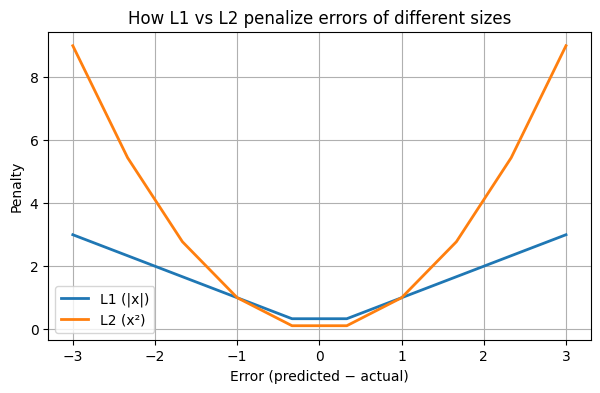

In [56]:
# How differently does each norm penalizes error

errors = np.linspace(-3, 3, 10)
l1_values   = np.abs(errors)
l2_values   = errors ** 2

plt.figure(figsize=(7, 4))
plt.plot(errors, l1_values, label='L1 (|x|)', linewidth=2)
plt.plot(errors, l2_values, label='L2 (x²)',  linewidth=2)
plt.xlabel('Error (predicted − actual)')
plt.ylabel('Penalty')
plt.legend()
plt.grid(True)
plt.title("How L1 vs L2 penalize errors of different sizes")
plt.show()